# MSCS 634 – Lab 3: K-Means and K-Medoids Clustering

**Name:** Anusha Sharma  
**Course:** MSCS 634 – Advanced Big Data and Data Mining  
**Lab:** Lab 3 – Clustering Using the Wine Dataset

##Objective

This experiment seeks to explore and analyze the behavior of two clustering algorithms, namely K-Means and K-Medoids on Wine Dataset from sklearn library. The dataset will be pre-processed for standardization, after which the performance of the two models will be assessed using Silhouette Score and Adjusted Rand Index (ARI). Visualization and comparison of the clustering will be done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

print("Libraries imported successfully!")

Libraries imported successfully!


Wine Dataset Exploration

In [5]:
# Load the Wine Dataset
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

# Create DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

# Explore the dataset
print("Dataset Shape:", df.shape)

print("\nFeature Names:")
print(wine.feature_names)

print("\nClass Names:")
print(wine.target_names)

print("\nClass Distribution:")
print(df["target"].value_counts().sort_index())

# Display first 5 rows
df.head()

Dataset Shape: (178, 14)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class Names:
['class_0' 'class_1' 'class_2']

Class Distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Data Standardization**

In [6]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display results
print("Original Data Shape:", X.shape)
print("Standardized Data Shape:", X_scaled.shape)

# Show first 5 standardized rows
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

Original Data Shape: (178, 13)
Standardized Data Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874



**Implementation of K-Means Clustering with k=3**

K-Means clustering algorithm is performed with k=3 due to the nature of Wine Dataset that consists of three known classes. Samples in the cluster are grouped together depending on their proximity to the cluster centroid.

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Create K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Train the model and obtain cluster labels
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate evaluation metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

# Display results
print("K-Means Clustering Results")
print("--------------------------")
print("Number of Clusters: 3")
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Adjusted Rand Index (ARI):", round(kmeans_ari, 4))

K-Means Clustering Results
--------------------------
Number of Clusters: 3
Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975



##Clustering of K-Medoids

K-Medoids clustering algorithm is performed with k=3 on the Wine Dataset after the dataset was standardized. As opposed to K-Means, which uses means of the observations as the cluster center, K-Medoids clustering uses actual data points as cluster centers.

****

In [8]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 6.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154561 sha256=66a48b837f4813ade87a833772c885e523d5cacb67d0d27a5fd401c9c4d4c483
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


In [9]:
from sklearn_extra.cluster import KMedoids

# Create K-Medoids model with 3 clusters
kmedoids = KMedoids(
    n_clusters=3,
    random_state=42,
    method='pam'
)

# Train the model and obtain cluster labels
kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Calculate evaluation metrics
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

# Display results
print("K-Medoids Clustering Results")
print("----------------------------")
print("Number of Clusters: 3")
print("Silhouette Score:", round(kmedoids_silhouette, 4))
print("Adjusted Rand Index (ARI):", round(kmedoids_ari, 4))

K-Medoids Clustering Results
----------------------------
Number of Clusters: 3
Silhouette Score: 0.2676
Adjusted Rand Index (ARI): 0.7411


**Visualization of K-Means and K-Medoids**

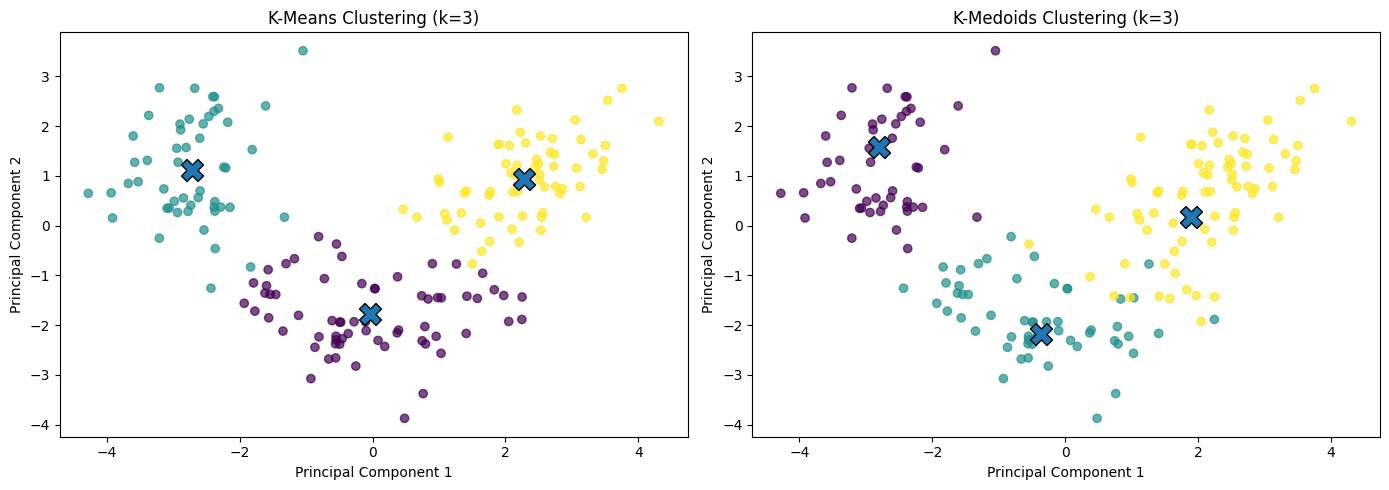

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce standardized data to 2 dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform K-Means centroids into PCA space
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)

# Get K-Medoids medoid points and transform into PCA space
kmedoids_centers_pca = pca.transform(
    X_scaled[kmedoids.medoid_indices_]
)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.7
)

axes[0].scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    marker='X',
    s=250,
    edgecolor='black'
)

axes[0].set_title('K-Means Clustering (k=3)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# K-Medoids
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmedoids_labels,
    cmap='viridis',
    alpha=0.7
)

axes[1].scatter(
    kmedoids_centers_pca[:, 0],
    kmedoids_centers_pca[:, 1],
    marker='X',
    s=250,
    edgecolor='black'
)

axes[1].set_title('K-Medoids Clustering (k=3)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()


**Comparison of Clustering**

Performance comparison between K-Means and K-Medoids is done through Silhouette Score and Adjusted Rand Index (ARI). Higher values of Silhouette Score imply well-separated and distinct clustering, whereas high values of ARI show high similarity between generated and actual Wine Dataset cluster groups.

In [11]:
# Create comparison table
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Medoids'],
    'Silhouette Score': [
        round(kmeans_silhouette, 4),
        round(kmedoids_silhouette, 4)
    ],
    'Adjusted Rand Index (ARI)': [
        round(kmeans_ari, 4),
        round(kmedoids_ari, 4)
    ]
})

comparison

,Algorithm,Silhouette Score,Adjusted Rand Index (ARI)
0,K-Means,0.2849,0.8975
1,K-Medoids,0.2676,0.7411


**Analysis and Observations**

According to the findings, K-Means showed greater performance than K-Medoids in clustering the standardized Wine Dataset. K-Means produced higher Silhouette Score, meaning that the clusters produced by this method were more compact and well-separated. Furthermore, K-Means yielded a higher Adjusted Rand Index (ARI), which indicates better correspondence between the created clusters and actual wine types.

According to the visualization, both methods managed to detect some clusters in the given data, but some overlap between the clusters could be observed. Cluster centers are also slightly different as K-Means calculates centroids for the clusters, while K-Medoids selects real observations as medoids.

Based on the evaluation measures used, K-Means seems to be the preferred clustering method for the provided data set. K-Means should be applied when the data contains relatively compact clusters and efficiency matters. K-Medoids could be preferable when there are outliers in the dataset as it is less sensitive to them as it selects the actual data points as medoids.


**Challenges and Decisions**

A first challenge with K-Medoids in this lab is that the algorithm is not present in the standard sklearn clustering library. Scikit-learn-extra library was used for KMedoids.

A critical decision was to perform feature scaling on the data before clustering since the Wine Dataset features have varying numeric ranges. In order to prevent domination of features with bigger numeric range during the clustering, StandardScaler was applied.

PCA was used for dimensionality reduction to two principal components to be able to display K-Means and K-Medoids clustering results in two-dimensional scatter plot.



**Conclusion**

In this experiment, K-Means and K-Medoids were employed in analyzing the Wine Dataset in practice. Since the data in the Wine Dataset include 13 features of various numerical ranges, standardization was performed with the use of the StandardScaler before clustering since we needed to make sure that each feature makes an equally good contribution to the calculation of distances by the clustering algorithms.

K-Means and K-Medoids were tested on their ability to classify three types of wine in the Wine Dataset by setting k = 3. The quality of both algorithms was measured with the help of the Silhouette Score and ARI. K-Means gave approximately Silhouette Score of 0.2849 and ARI of 0.8975, and K-Medoids scored Silhouette Score of 0.2676 and ARI of 0.7411. This suggests that clusters generated by K-Means are more separated and aligned with the classes of wine than those created by K-Medoids.

For visualization purposes, PCA was applied to the dataset in order to reduce the number of features to two. Scatter plot shows us that both algorithms were able to detect cluster structures, though there is some overlap. Generally, K-Means worked better with the Wine Dataset. Nonetheless, K-Medoids might come in handy when dealing with outliers as cluster centers are real observations.